#K-MEANS CLUSTERING FOR CARDIOVASCULAR LIFESTYLE PATTERNS
# References:
 - Scikit-Learn KMeans: https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html
 - StandardScaler: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html
 - MacQueen (1967): Original K-Means algorithm
 - Thorndike (1953): Elbow Method
 - Copilot

#Imports

In [1]:
import pandas as pd #We use pandas it to load, clean, and manipulate datasets for example, reading your lifestyle factors excel file into a dataframe and preparing it for analysis
import numpy as np #Numpy provides fast array operations and mathematical functions, we use it for the clustering calculations
from sklearn.preprocessing import StandardScaler #There we are doing preprocessing to standardise features so theyre on the same scale
from sklearn.cluster import KMeans #We are importing kmeans to cluster the lifestyle patterns
import matplotlib.pyplot as plt #This creates charts and graphs to visualise results so we can interpret them

#Loading dataset

In [2]:
df = pd.read_excel('LifestyleFactorsDataCollection.xlsx')

#Cleaning

In [3]:
#Removing timestamp column since its not needed for clustering
df = df.drop(columns=['Timestamp'])

#Renaming columns for clarity
df.columns = ['age', 'smoking_status', 'exercise_per_week', 'average_sleep', 'resting_heart_rate']

#Converting smoking to numeric as ML algorithms cant process catigorical data
df['smoking_status'] = df['smoking_status'].map({'no': 0, 'yes': 1}) #(0 = no, 1 = yes)

#Keeping the realistic values
df = df[
    (df['resting_heart_rate'] >= 40) & (df['resting_heart_rate'] <= 120) &
    (df['average_sleep'] >= 3) & (df['average_sleep'] <= 12) &
    (df['exercise_per_week'] >= 0) & (df['exercise_per_week'] <= 7) &
    (df['age'] >= 15) & (df['age'] <= 60)]

#Selecting features based on strong predictors
smoking, excersise, sleep, resting heart rate

In [4]:
X = df[['exercise_per_week', 'average_sleep', 'smoking_status', 'resting_heart_rate']]

#Standardising features

In [5]:
#We first put all features on the same scale so they’re fair
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#Give more weight to rhr, this ensures the algorithm pays closer attention to cardiovascular health, rather than treating all lifestyle factors equally
X_scaled[:, 3] = X_scaled[:, 3] * 1.5 #Multiplying by 1.5 increases the values of that feature by 50%.

#Elbow method to find K

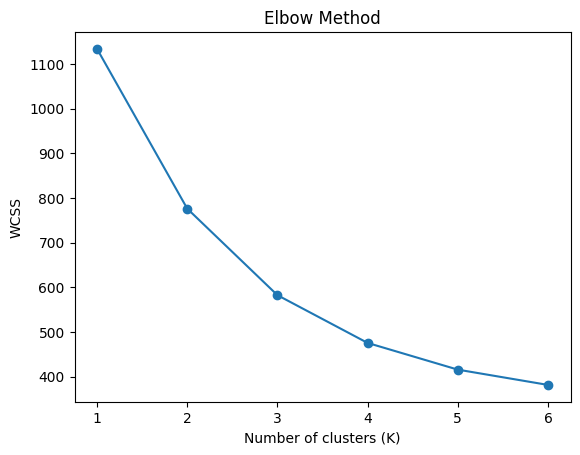

In [6]:
#WCSS stands for "Within‑Cluster Sum of Squares", its the sum of squared distances between each data point and the centroid of the cluster it belongs to, smaller values = tighter, better clusters
#Inertia is just the scikit‑learn name for WCSS
#We fix the random state so results don’t change each time
#Then we plot WCSS for different K values and look for the elbow which is the point where adding more clusters stops making a big difference
wcss = []
for k in range(1, 7):
    kmeans = KMeans(n_clusters=k, random_state=50)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)  # inertia_ = WCSS

plt.plot(range(1, 7), wcss, marker='o')
plt.xlabel('Number of clusters (K)')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

###INTERPRETATION
- This graph helps us choose how many clusters to use.
- WCSS shows how tight the groups are. It drops quickly at first, then slows down.
- The elbow is around 3 clusters so where adding more doesn’t make a big difference, so 3 is the best choice.

#Fit Kmeans with the K found in elbow method

In [7]:
#We tell the algorithm to split the data into 3 clusters, this number comes from the elbow method we tested earlier
#Setting a random state makes sure we get the same result every time we run it, instead of slightly different clusters
kmeans = KMeans(n_clusters=3, random_state=50)
kmeans.fit(X_scaled) #where our algorithm runs on our scaled data, it finds the 3 cluster centers and assigns each data point to the nearest one
df['cluster'] = kmeans.labels_ #K‑Means gives each row a label (0, 1, or 2) showing which cluster it belongs to. We add that label as a new column in our dataset, so now every person has a cluster ID

#Centroids

In [8]:
#A centroid is the mathematical center of a cluster, it’s the ‘average lifestyle profile’ of everyone in that group, KMeans uses centroids to decide which cluster each person belongs to
#Get the cluster centers (the “average point” of each cluster)
centroids_scaled = kmeans.cluster_centers_

#Convert them back to the original units so they make sense, for example instead of seeing scaled values like 0.5 which tell us nothing, we will see "7hrs of sleep"
centroids_original = scaler.inverse_transform(centroids_scaled)

#Put the cluster centers into a dataframe with clear column names for interpretation
centroids_df = pd.DataFrame(
    centroids_original,
    columns=['exercise_per_week', 'average_sleep', 'smoking_status', 'resting_heart_rate'])
print("CENTROIDS - cluster avgs")
print(centroids_df.round(2)) #To see a clearer difference between values

CENTROIDS - cluster avgs
   exercise_per_week  average_sleep  smoking_status  resting_heart_rate
0               2.15           7.04            -0.0               77.88
1               4.51           7.38             0.0               54.96
2               2.29           6.17             1.0               78.15


### INTERPRETATION
- Each cluster represents an average lifestyle profile.
- Cluster 0 is in the middle; non‑smoker with average sleep, but still a high heart rate. (due to floating‑point math in Python, sometimes 0.0 is displayed as -0.0, it still means 0)
- Cluster 1 shows the healthiest habits; more exercise, good sleep, non‑smoker, low heart rate.
- Cluster 2 shows the riskiest profile; less exercise, less sleep, smoker, high heart rate.

#Visualisation

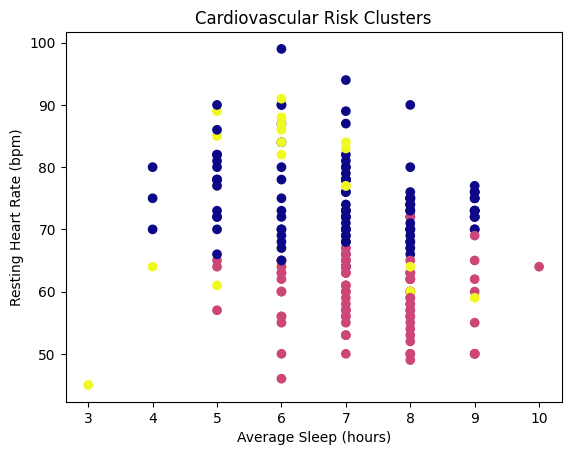

In [11]:
plt.scatter(df['average_sleep'], df['resting_heart_rate'], c=df['cluster'], cmap='plasma') #Plasma color map to make the clusters stand out with bright, clear colors
plt.xlabel('Average Sleep (hours)')
plt.ylabel('Resting Heart Rate (bpm)')
plt.title('Cardiovascular Risk Clusters')
plt.show()

###INTERPRETATION OF THE RESULTS

- we chose rhr because it’s a direct indicator of heart efficiency and stress. A higher RHR signals poor cardiovascular fitness, stress etc. while a lower RHR suggests better recovery and endurance.In clustering, RHR helps us differentiate risk levels: people with higher heart rates tend to fall into higher‑risk groups.
- we chose sleep because sleep affects heart rate, blood pressure and recovery. Poor sleep is linked to higher stress hormones and increased cardiovascular risk. Consistent, quality sleep supports heart health and metabolic balance.
- Each colour represents a different cluster of individuals with similar sleep and heart rate patterns
- People with higher resting heart rates cluster in the dark blue group, suggesting potential cardiovascular strain or poor recovery.
- Those with moderate heart rates form the yellow cluster, indicating balanced sleep‑heart patterns.
- The pink cluster with low heart rate represent individuals with better cardiovascular fitness or lower stress levels.
- in conclusion with my dataset, short sleepers with high heart rates may need lifestyle adjustments, while consistent sleepers with lower heart rates show healthier patterns.
- theres some scattered points instead of neat clustering because it reflects reality, some people’s sleep and heart rate patterns overlap with multiple groups. This teaches us that health data is complex, and clustering helps us see both clear risk groups and those in the middle ground.